In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q transformers datasets torch accelerate evaluate scikit-learn

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from datasets import Dataset, DatasetDict, load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate

In [4]:
# 1. Define your exact storage location paths
EXPORT_DIR = "/content/drive/MyDrive/AIE_Project/intent_classification_datasets/"
train_path = f"{EXPORT_DIR}train_cleaned_balanced.csv"
val_path = f"{EXPORT_DIR}val_cleaned.csv"

# 2. Use Hugging Face to load the separate split files directly into a unified object
raw_datasets = load_dataset('csv', data_files={
    'train': train_path,
    'validation': val_path
})


# 3. Dynamically extract the unique text categories for labeling consistency
# We read from the validation set because it preserves your natural, un-duplicated categories
df_val_reference = pd.read_csv(val_path)
unique_labels = sorted(df_val_reference["label"].unique().tolist())

# 4. Print structured metrics to confirm the files match perfectly
print("==========================================================")
print("             DATA SPLIT LOAD REPORT                      ")
print("==========================================================\n")
print(f"✅ Total Unique Classes Loaded: {len(unique_labels)}")
print(f" -> Balanced Training Set Size : {len(raw_datasets['train'])} rows")
print(f" -> Natural Validation Set Size: {len(raw_datasets['validation'])} rows")
print(f"\nDetected Classes: {unique_labels}")


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

             DATA SPLIT LOAD REPORT                      

✅ Total Unique Classes Loaded: 9
 -> Balanced Training Set Size : 6300 rows
 -> Natural Validation Set Size: 1190 rows

Detected Classes: ['complaint', 'general_question', 'logistics', 'payment', 'product_inquiry', 'refund', 'self_harm_or_suicide_risk', 'technical_support', 'unknown']


In [5]:
# 1. Base model architecture selection
MODEL_NAME = "distilbert-base-uncased"

# 2. Build explicit mappings from the unique labels list (defined in cell 3)
id2label_clean = {str(idx): label for idx, label in enumerate(unique_labels)}
label2id_clean = {label: idx for idx, label in enumerate(unique_labels)}

# 3. Label Mapping Function to convert string labels into numeric integers
def encode_labels(example):
    # Converts string text label e.g., "refund" to 5
    example["label"] = label2id_clean[example["label"]]
    return example

# Apply label integer conversion to your train and validation sets
encoded_datasets = raw_datasets.map(encode_labels)

# 4. Load the tokenizer matching the core encoder model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    # Truncate and pad text strings to ensure uniform input length matrix dimensions
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Tokenize the data rows using our integer-mapped dataset
tokenized_datasets_raw = encoded_datasets.map(tokenize_function, batched=True)

# 5. Explicitly remove the raw 'text' string column so PyTorch doesn't try to tensor-ize it
columns_to_remove = [col for col in tokenized_datasets_raw["train"].column_names if col not in ["label", "input_ids", "attention_mask"]]
tokenized_datasets = tokenized_datasets_raw.remove_columns(columns_to_remove)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 6. Instantiate the architecture with explicit dynamic class configurations
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(unique_labels),
    id2label=id2label_clean,
    label2id=label2id_clean
)

# 7. Connect standard metric logging evaluation frameworks
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

print(f"✅ Tokenizer and Model successfully initialized for {len(unique_labels)} classes!")
print(f"Kept features for training tensor conversion: {tokenized_datasets['train'].column_names}")


Map:   0%|          | 0/6300 [00:00<?, ? examples/s]

Map:   0%|          | 0/1190 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1190 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Tokenizer and Model successfully initialized for 9 classes!
Kept features for training tensor conversion: ['label', 'input_ids', 'attention_mask']


In [6]:
training_args = TrainingArguments(
    output_dir="/content/intent_model",
    learning_rate=2e-5,                  # Fast, stable fine-tuning learning rate
    per_device_train_batch_size=16,       # Scaled batch sizing for T4 GPU acceleration
    per_device_eval_batch_size=16,
    num_train_epochs=6,                  # Balanced iteration count over the larger dataset
    weight_decay=0.1,
    eval_strategy="epoch",               # Evaluate accuracy metrics after each training loop pass
    save_strategy="epoch",
    load_best_model_at_end=True,         # Track and reload optimal state weights automatically
    metric_for_best_model="eval_loss",   # Tracks loss calculation directly
    greater_is_better=False,             # We want the lowest possible validation loss
    logging_steps=20,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Execute model training
trainer.train()

# Permanently persist model weights and configurations cleanly to storage disk
model.save_pretrained("/content/intent_model")
tokenizer.save_pretrained("/content/intent_model")
print("\n🎉 Training Complete! Clean model saved to /content/intent_model")


Epoch,Training Loss,Validation Loss,Accuracy
1,0.020253,0.013832,0.999160
2,0.003580,0.003519,0.999160
3,0.001805,0.002394,0.999160
4,0.001310,0.002589,0.999160
5,0.000990,0.002199,0.999160
6,0.000942,0.002187,0.999160


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training Complete! Clean model saved to /content/intent_model


In [7]:
# 1. Run model predictions across the 15% validation split dataset
validation_output = trainer.predict(tokenized_datasets["validation"])

# 2. Extract the predicted class IDs and actual ground-truth label IDs
predicted_class_ids = np.argmax(validation_output.predictions, axis=-1)
true_class_ids = validation_output.label_ids

# 3. Print the comprehensive classification matrix report
print("==========================================================")
print("             FINAL MODEL TRAINING PERFORMANCE REPORT      ")
print("==========================================================\n")

print(classification_report(
    true_class_ids,
    predicted_class_ids,
    target_names=unique_labels,
    digits=4
))


             FINAL MODEL TRAINING PERFORMANCE REPORT      

                           precision    recall  f1-score   support

                complaint     1.0000    1.0000    1.0000       150
         general_question     1.0000    1.0000    1.0000       147
                logistics     1.0000    1.0000    1.0000       103
                  payment     1.0000    1.0000    1.0000       114
          product_inquiry     1.0000    0.9925    0.9962       133
                   refund     1.0000    1.0000    1.0000       137
self_harm_or_suicide_risk     1.0000    1.0000    1.0000       150
        technical_support     1.0000    1.0000    1.0000       150
                  unknown     0.9907    1.0000    0.9953       106

                 accuracy                         0.9992      1190
                macro avg     0.9990    0.9992    0.9991      1190
             weighted avg     0.9992    0.9992    0.9992      1190



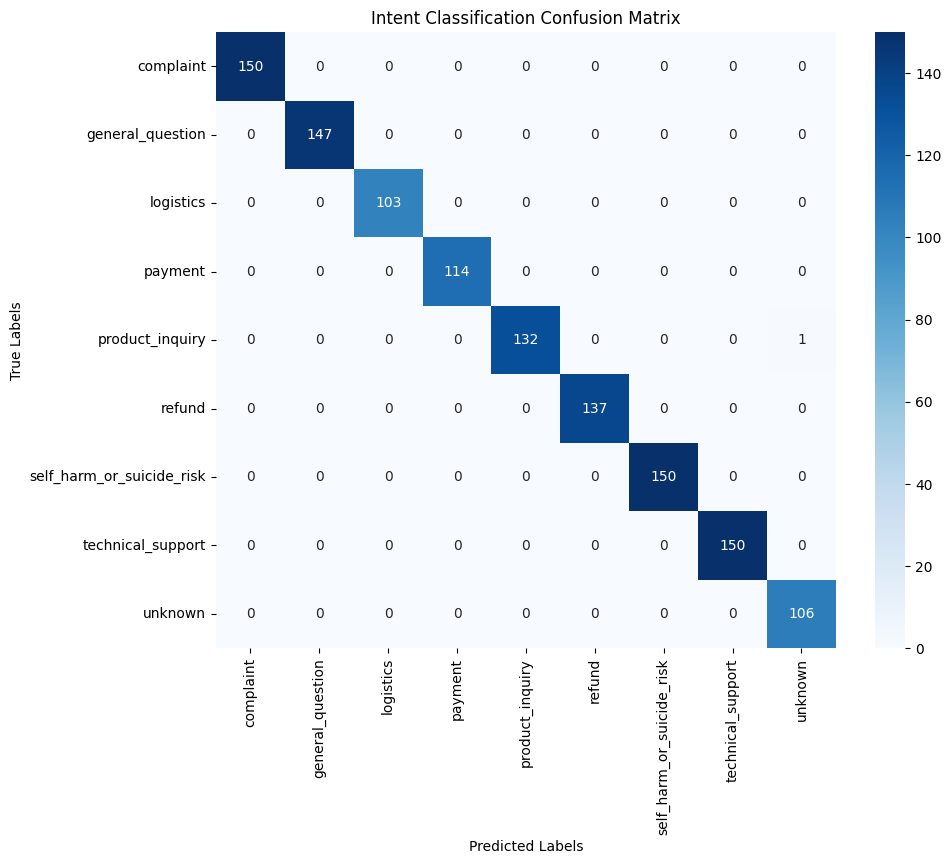

In [8]:
# 1. Gather true labels and model predictions across validation data
predictions = trainer.predict(tokenized_datasets["validation"])
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# 2. Compute matrix configuration layout
cm = confusion_matrix(true_labels, preds)

# 3. Plot chart map
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=unique_labels, yticklabels=unique_labels, cmap="Blues")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Intent Classification Confusion Matrix')
plt.show()
